In [15]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (8).csv


In [25]:
# Load dataset
df = pd.read_csv("retail_sales_dataset.csv")
# Show the first few rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [26]:
# Check the data structure
df.info()
# Look at the summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [21]:
# Check for missing data
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [27]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [28]:
# Product category counts
df["Product Category"].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [29]:
# Revenue by category
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


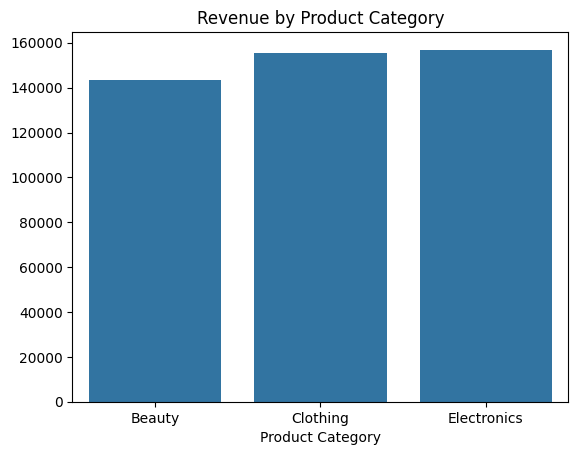

In [32]:
# Visualization Revenue by product category
sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Revenue by Product Category")
plt.show()

Revenue is highest for electronics and lowest for beauty products.

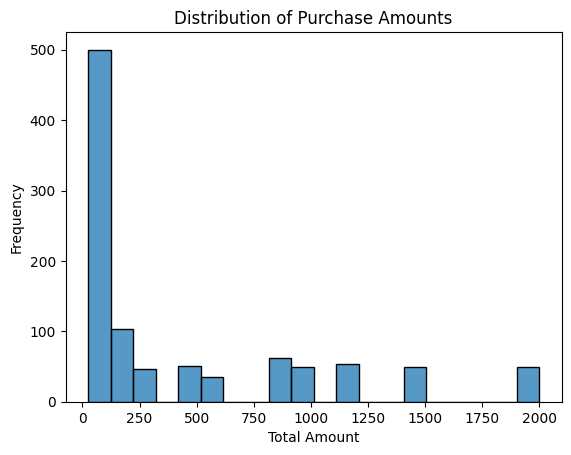

In [33]:
# Sales distribution
sns.histplot(df["Total Amount"], bins=20)

plt.title("Distribution of Purchase Amounts")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

Most puchases fall between \$50-\$125.











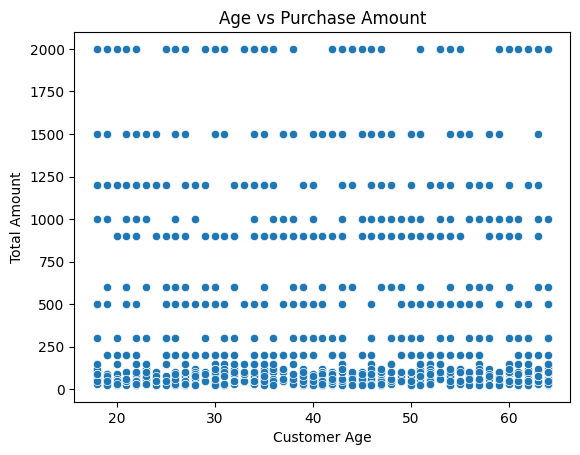

In [35]:
# Age vs Spending
sns.scatterplot(x="Age", y="Total Amount", data=df)

plt.title("Age vs Purchase Amount")
plt.xlabel("Customer Age")
plt.ylabel("Total Amount")

plt.show()

Customer age seems to not strongly influence purchase amount. The distribution is similar across all age groups.

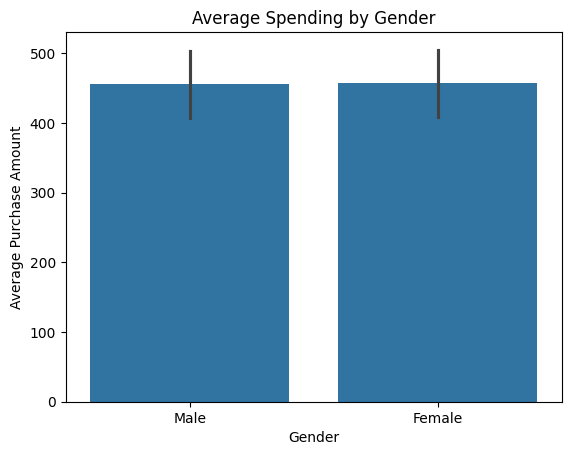

In [36]:
# Sales by gender
sns.barplot(x="Gender", y="Total Amount", data=df)

plt.title("Average Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount")

plt.show()

There is no strong relationship between gender and average purchase amount. Purchase amounts are equivalent regardless of gender.

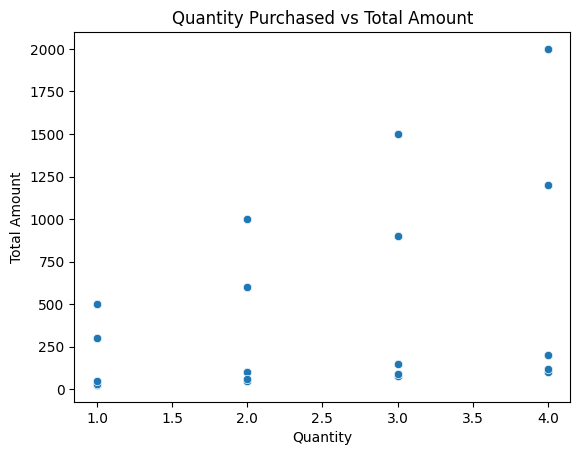

In [37]:
# Quantity vs revenue
sns.scatterplot(x="Quantity", y="Total Amount", data=df)

plt.title("Quantity Purchased vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")

plt.show()

Transactions with higher quanities tend to result lin a larger total purchase amount. This shows a positive relationship between quanitity purchased and revenue.

The highest revenue transactions happen when there are multiple items purchased.

Not all higher quanitity purchases generate a large purchase amount.

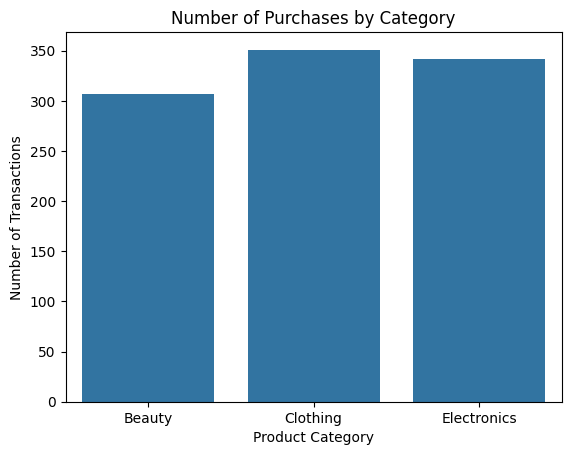

In [38]:
# Product Category Distribution
sns.countplot(x="Product Category", data=df)

plt.title("Number of Purchases by Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")

plt.show()

Clothing has the highest number of transactions, indicating it is the most frequently purchased category. Electronics follows closely behind, while Beauty has the lowest purchase frequency. This suggests clothing items may have higher demand or be purchased more regularly than other categories.